# 03 - Dataset Analysis & Visualization for YOLOv8 Retail Theft Detection

**Purpose:** Comprehensive analysis and visualization of the dataset

**Outputs:**
- Class distribution bar chart
- Bounding box size and aspect-ratio distributions
- Image resolution distribution
- Grid of labeled image samples
- Train/Validation/Test split statistics
- Dataset summary report
- Class imbalance analysis
- Recommendations for YOLOv8s training

---

## 1. Setup and Imports

In [1]:
# Install required packages
!pip install opencv-python pillow numpy pandas matplotlib seaborn tqdm pyyaml --quiet

In [2]:
import os
import sys
import cv2
import yaml
import json
import random
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All imports successful!")

All imports successful!


In [3]:
# Configuration
BASE_DIR = Path(r"c:/Users/shaho/OneDrive - Nile University/Desktop/AletrixGrad")

# Use cleaned dataset if available, otherwise use original
CLEANED_DIR = BASE_DIR / "dataset_cleaned"
ORIGINAL_DIR = BASE_DIR / "cc-tv-footage-annotation-b8-lcysc-b1-2"

if CLEANED_DIR.exists() and (CLEANED_DIR / "train" / "images").exists():
    DATASET_DIR = CLEANED_DIR
    print(f"Using cleaned dataset: {DATASET_DIR}")
else:
    DATASET_DIR = ORIGINAL_DIR
    print(f"Using original dataset: {DATASET_DIR}")

OUTPUT_DIR = BASE_DIR / "outputs"
VIS_DIR = BASE_DIR / "visualizations"

# Create directories
OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

# Class definitions
CLASS_NAMES = {
    0: 'Customer-Bagpack',
    1: 'Product',
    2: 'Product-Picked',
    3: 'Shopping-Cart',
    4: 'normal',
    5: 'theft'
}

# Color palette for classes (RGB)
CLASS_COLORS = {
    0: (255, 127, 14),   # Orange - Customer-Bagpack
    1: (44, 160, 44),    # Green - Product
    2: (214, 39, 40),    # Red - Product-Picked
    3: (148, 103, 189),  # Purple - Shopping-Cart
    4: (31, 119, 180),   # Blue - normal
    5: (227, 26, 28)     # Dark Red - theft
}

NUM_CLASSES = 6
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

print(f"\nNumber of Classes: {NUM_CLASSES}")
print(f"Classes: {list(CLASS_NAMES.values())}")

Using cleaned dataset: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\dataset_cleaned

Number of Classes: 6
Classes: ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']


## 2. Data Loading Functions

In [4]:
def load_annotations(label_path: Path) -> List[Dict]:
    """Load YOLO annotations from a label file."""
    annotations = []
    
    if not label_path.exists():
        return annotations
    
    try:
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                parts = line.split()
                if len(parts) == 5:
                    try:
                        annotations.append({
                            'class_id': int(parts[0]),
                            'x_center': float(parts[1]),
                            'y_center': float(parts[2]),
                            'width': float(parts[3]),
                            'height': float(parts[4])
                        })
                    except ValueError:
                        pass
    except Exception as e:
        print(f"Error reading {label_path}: {e}")
    
    return annotations


def get_image_dimensions(image_path: Path) -> Tuple[int, int]:
    """Get image dimensions without loading the entire image."""
    try:
        with Image.open(image_path) as img:
            return img.size  # (width, height)
    except Exception:
        return (0, 0)


def load_dataset_stats(dataset_path: Path) -> Dict:
    """Load complete dataset statistics."""
    stats = {
        'splits': {},
        'class_counts': defaultdict(int),
        'bbox_data': [],
        'image_data': [],
        'annotations_per_image': []
    }
    
    for split in ['train', 'valid', 'test']:
        split_path = dataset_path / split
        images_path = split_path / "images"
        labels_path = split_path / "labels"
        
        if not images_path.exists():
            continue
        
        split_stats = {
            'num_images': 0,
            'num_annotations': 0,
            'class_counts': defaultdict(int)
        }
        
        image_files = [f for f in images_path.iterdir() 
                       if f.suffix.lower() in IMAGE_EXTENSIONS]
        split_stats['num_images'] = len(image_files)
        
        for img_path in tqdm(image_files, desc=f"Loading {split}"):
            # Get image dimensions
            width, height = get_image_dimensions(img_path)
            if width == 0 or height == 0:
                continue
            
            stats['image_data'].append({
                'split': split,
                'file': img_path.name,
                'width': width,
                'height': height,
                'aspect_ratio': width / height
            })
            
            # Load annotations
            label_path = labels_path / (img_path.stem + '.txt')
            annotations = load_annotations(label_path)
            
            stats['annotations_per_image'].append({
                'split': split,
                'file': img_path.name,
                'num_annotations': len(annotations)
            })
            
            split_stats['num_annotations'] += len(annotations)
            
            for ann in annotations:
                class_id = ann['class_id']
                split_stats['class_counts'][class_id] += 1
                stats['class_counts'][class_id] += 1
                
                # Calculate bbox statistics
                bbox_width = ann['width']
                bbox_height = ann['height']
                
                # Convert to pixel dimensions
                pixel_width = bbox_width * width
                pixel_height = bbox_height * height
                
                stats['bbox_data'].append({
                    'split': split,
                    'class_id': class_id,
                    'class_name': CLASS_NAMES.get(class_id, f'Unknown-{class_id}'),
                    'norm_width': bbox_width,
                    'norm_height': bbox_height,
                    'norm_area': bbox_width * bbox_height,
                    'pixel_width': pixel_width,
                    'pixel_height': pixel_height,
                    'pixel_area': pixel_width * pixel_height,
                    'aspect_ratio': bbox_width / bbox_height if bbox_height > 0 else 0
                })
        
        stats['splits'][split] = split_stats
    
    return stats

In [5]:
# Load dataset statistics
print("Loading dataset statistics...")
dataset_stats = load_dataset_stats(DATASET_DIR)
print("\nDone!")

Loading dataset statistics...


Loading test: 100%|██████████| 256/256 [00:02<00:00, 120.32it/s]


Done!


## 3. Dataset Overview

In [6]:
# Convert to DataFrames for analysis
bbox_df = pd.DataFrame(dataset_stats['bbox_data'])
image_df = pd.DataFrame(dataset_stats['image_data'])
annot_df = pd.DataFrame(dataset_stats['annotations_per_image'])

print("="*70)
print("DATASET OVERVIEW")
print("="*70)

total_images = len(image_df)
total_annotations = len(bbox_df)

print(f"\nTotal Images: {total_images:,}")
print(f"Total Annotations: {total_annotations:,}")
print(f"Average Annotations per Image: {total_annotations / total_images:.2f}" if total_images > 0 else "N/A")

print("\n" + "-"*70)
print("SPLIT DISTRIBUTION")
print("-"*70)

for split, split_data in dataset_stats['splits'].items():
    pct = split_data['num_images'] / total_images * 100 if total_images > 0 else 0
    print(f"\n{split.upper()}:")
    print(f"  Images:      {split_data['num_images']:,} ({pct:.1f}%)")
    print(f"  Annotations: {split_data['num_annotations']:,}")

DATASET OVERVIEW

Total Images: 2,052
Total Annotations: 7,335
Average Annotations per Image: 3.57

----------------------------------------------------------------------
SPLIT DISTRIBUTION
----------------------------------------------------------------------

TRAIN:
  Images:      1,314 (64.0%)
  Annotations: 4,726

VALID:
  Images:      482 (23.5%)
  Annotations: 1,767

TEST:
  Images:      256 (12.5%)
  Annotations: 842


## 4. Class Distribution Analysis

In [7]:
# Class distribution
print("\n" + "="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)

class_counts = dict(dataset_stats['class_counts'])
total_annots = sum(class_counts.values())

print("\nOverall Class Distribution:")
print("-"*50)

class_data = []
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    pct = count / total_annots * 100 if total_annots > 0 else 0
    name = CLASS_NAMES.get(class_id, f'Unknown-{class_id}')
    bar = '█' * int(pct / 2)
    print(f"  {class_id}: {name:20s} {count:6,} ({pct:5.1f}%) {bar}")
    class_data.append({'class_id': class_id, 'class_name': name, 'count': count, 'percentage': pct})

class_dist_df = pd.DataFrame(class_data)


CLASS DISTRIBUTION ANALYSIS

Overall Class Distribution:
--------------------------------------------------
  0: Customer-Bagpack        605 (  8.2%) ████
  1: Product                 793 ( 10.8%) █████
  2: Product-Picked          778 ( 10.6%) █████
  3: Shopping-Cart           137 (  1.9%) 
  4: normal                4,626 ( 63.1%) ███████████████████████████████
  5: theft                   396 (  5.4%) ██


In [8]:
# Class imbalance analysis
print("\n" + "-"*70)
print("CLASS IMBALANCE ANALYSIS")
print("-"*70)

counts = list(class_counts.values())
max_count = max(counts)
min_count = min(counts)
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

majority_class = CLASS_NAMES[max(class_counts, key=class_counts.get)]
minority_class = CLASS_NAMES[min(class_counts, key=class_counts.get)]

print(f"\nMajority Class:   {majority_class} ({max_count:,} samples)")
print(f"Minority Class:   {minority_class} ({min_count:,} samples)")
print(f"Imbalance Ratio:  {imbalance_ratio:.1f}x")

# Severity assessment
if imbalance_ratio > 20:
    severity = "CRITICAL"
    print(f"\nSeverity: {severity} - Extreme class imbalance detected!")
elif imbalance_ratio > 10:
    severity = "HIGH"
    print(f"\nSeverity: {severity} - Significant class imbalance detected")
elif imbalance_ratio > 5:
    severity = "MODERATE"
    print(f"\nSeverity: {severity} - Moderate class imbalance")
else:
    severity = "LOW"
    print(f"\nSeverity: {severity} - Class distribution is acceptable")


----------------------------------------------------------------------
CLASS IMBALANCE ANALYSIS
----------------------------------------------------------------------

Majority Class:   normal (4,626 samples)
Minority Class:   Shopping-Cart (137 samples)
Imbalance Ratio:  33.8x

Severity: CRITICAL - Extreme class imbalance detected!


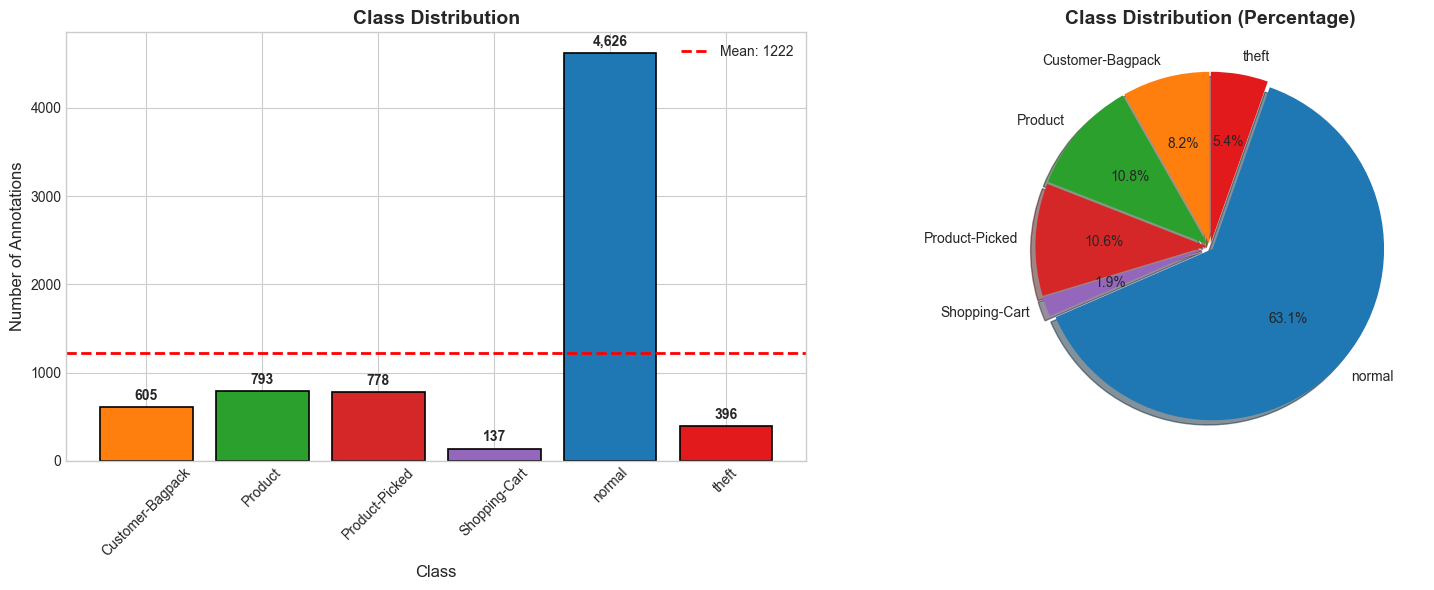


Saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\visualizations\class_distribution.png


In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
class_names_list = [CLASS_NAMES[i] for i in sorted(class_counts.keys())]
class_counts_list = [class_counts[i] for i in sorted(class_counts.keys())]
colors = [np.array(CLASS_COLORS[i]) / 255 for i in sorted(class_counts.keys())]

bars = axes[0].bar(class_names_list, class_counts_list, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Number of Annotations', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for bar, count in zip(bars, class_counts_list):
    height = bar.get_height()
    axes[0].annotate(f'{count:,}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add horizontal line for mean
mean_count = np.mean(class_counts_list)
axes[0].axhline(y=mean_count, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_count:.0f}')
axes[0].legend()

# Pie chart
explode = [0.02] * len(class_names_list)
wedges, texts, autotexts = axes[1].pie(class_counts_list, labels=class_names_list, 
                                        autopct='%1.1f%%', colors=colors, explode=explode,
                                        shadow=True, startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(VIS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {VIS_DIR / 'class_distribution.png'}")

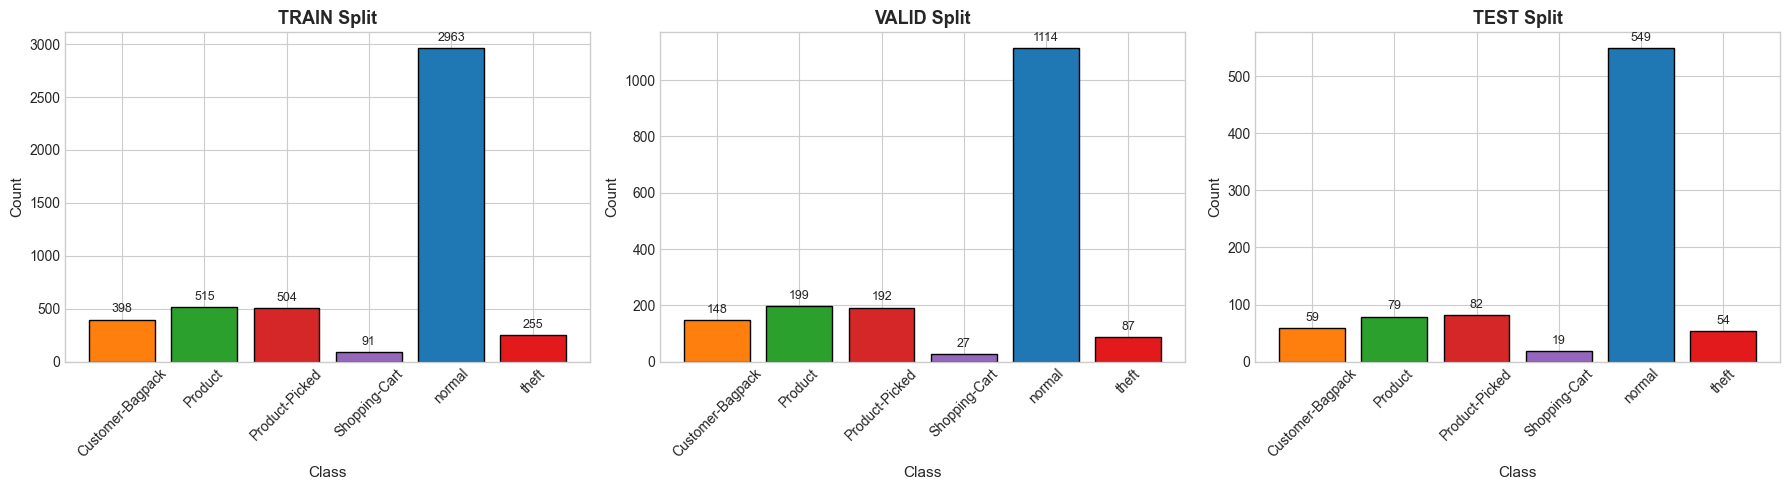

In [10]:
# Class distribution per split
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, split in enumerate(['train', 'valid', 'test']):
    if split not in dataset_stats['splits']:
        continue
    
    split_counts = dataset_stats['splits'][split]['class_counts']
    counts_list = [split_counts.get(i, 0) for i in sorted(class_counts.keys())]
    
    bars = axes[idx].bar(class_names_list, counts_list, color=colors, edgecolor='black')
    axes[idx].set_xlabel('Class', fontsize=11)
    axes[idx].set_ylabel('Count', fontsize=11)
    axes[idx].set_title(f'{split.upper()} Split', fontsize=13, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    
    for bar, count in zip(bars, counts_list):
        if count > 0:
            axes[idx].annotate(f'{count}',
                               xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                               xytext=(0, 3),
                               textcoords="offset points",
                               ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(VIS_DIR / 'class_distribution_per_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Bounding Box Analysis

In [11]:
# Bounding box statistics
print("\n" + "="*70)
print("BOUNDING BOX ANALYSIS")
print("="*70)

if len(bbox_df) > 0:
    print(f"\nTotal Bounding Boxes: {len(bbox_df):,}")
    print(f"\nNormalized Dimensions:")
    print(f"  Width  - Min: {bbox_df['norm_width'].min():.4f}, Max: {bbox_df['norm_width'].max():.4f}, Mean: {bbox_df['norm_width'].mean():.4f}")
    print(f"  Height - Min: {bbox_df['norm_height'].min():.4f}, Max: {bbox_df['norm_height'].max():.4f}, Mean: {bbox_df['norm_height'].mean():.4f}")
    print(f"  Area   - Min: {bbox_df['norm_area'].min():.6f}, Max: {bbox_df['norm_area'].max():.4f}, Mean: {bbox_df['norm_area'].mean():.4f}")
    print(f"\nAspect Ratio:")
    print(f"  Min: {bbox_df['aspect_ratio'].min():.3f}, Max: {bbox_df['aspect_ratio'].max():.3f}, Mean: {bbox_df['aspect_ratio'].mean():.3f}")


BOUNDING BOX ANALYSIS

Total Bounding Boxes: 7,335

Normalized Dimensions:
  Width  - Min: 0.0159, Max: 0.7949, Mean: 0.2176
  Height - Min: 0.0310, Max: 1.0000, Mean: 0.4071
  Area   - Min: 0.000632, Max: 0.7949, Mean: 0.1104

Aspect Ratio:
  Min: 0.108, Max: 2.516, Mean: 0.578


In [12]:
# Bbox statistics by class
print("\nBounding Box Statistics by Class:")
print("-"*70)

bbox_by_class = bbox_df.groupby('class_name').agg({
    'norm_area': ['mean', 'std', 'min', 'max'],
    'aspect_ratio': ['mean', 'std']
}).round(4)

print(bbox_by_class.to_string())


Bounding Box Statistics by Class:
----------------------------------------------------------------------
                 norm_area                         aspect_ratio        
                      mean     std     min     max         mean     std
class_name                                                             
Customer-Bagpack    0.0193  0.0222  0.0020  0.4233       0.5506  0.1875
Product             0.0148  0.0258  0.0006  0.1430       0.6789  0.3385
Product-Picked      0.2385  0.1781  0.0058  0.7949       0.7623  0.4322
Shopping-Cart       0.0341  0.0138  0.0040  0.0524       0.6013  0.3269
normal              0.1184  0.1111  0.0016  0.7369       0.5394  0.2487
theft               0.1219  0.1225  0.0174  0.6085       0.4900  0.1521


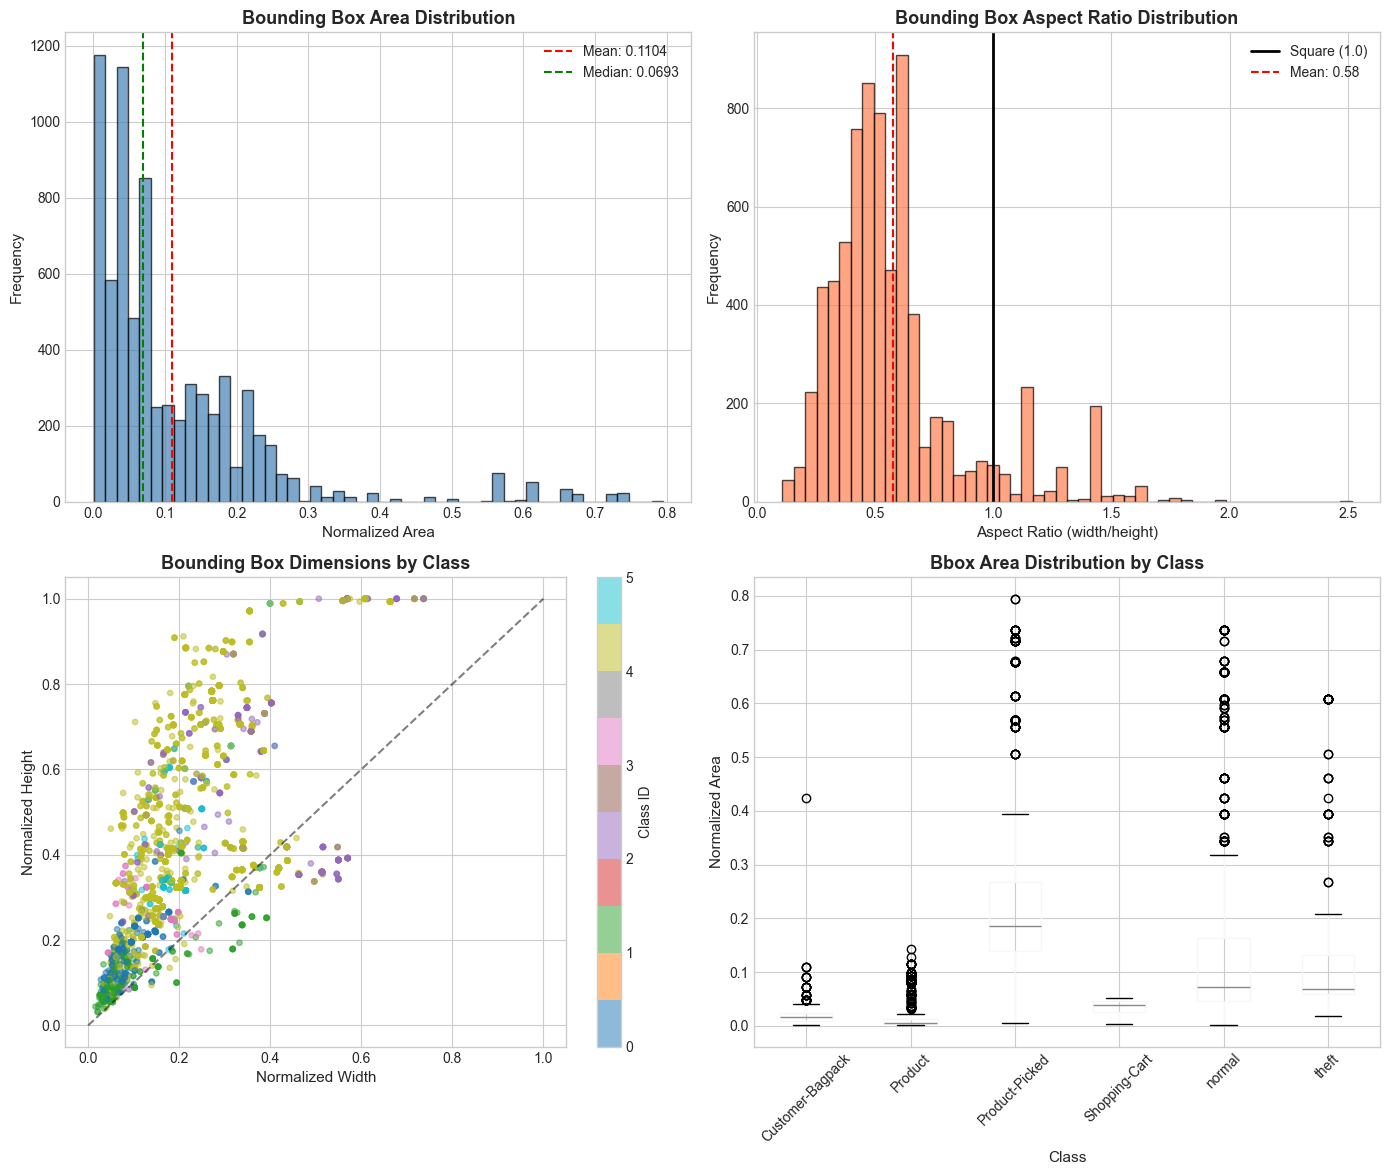

In [13]:
# Visualize bounding box distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Bbox size distribution (area)
axes[0, 0].hist(bbox_df['norm_area'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Normalized Area', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Bounding Box Area Distribution', fontsize=13, fontweight='bold')
axes[0, 0].axvline(bbox_df['norm_area'].mean(), color='red', linestyle='--', label=f'Mean: {bbox_df["norm_area"].mean():.4f}')
axes[0, 0].axvline(bbox_df['norm_area'].median(), color='green', linestyle='--', label=f'Median: {bbox_df["norm_area"].median():.4f}')
axes[0, 0].legend()

# 2. Aspect ratio distribution
axes[0, 1].hist(bbox_df['aspect_ratio'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Aspect Ratio (width/height)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Bounding Box Aspect Ratio Distribution', fontsize=13, fontweight='bold')
axes[0, 1].axvline(1.0, color='black', linestyle='-', linewidth=2, label='Square (1.0)')
axes[0, 1].axvline(bbox_df['aspect_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {bbox_df["aspect_ratio"].mean():.2f}')
axes[0, 1].legend()

# 3. Width vs Height scatter
sample_df = bbox_df.sample(min(3000, len(bbox_df)))
scatter = axes[1, 0].scatter(sample_df['norm_width'], sample_df['norm_height'],
                              c=sample_df['class_id'], cmap='tab10', alpha=0.5, s=15)
axes[1, 0].set_xlabel('Normalized Width', fontsize=11)
axes[1, 0].set_ylabel('Normalized Height', fontsize=11)
axes[1, 0].set_title('Bounding Box Dimensions by Class', fontsize=13, fontweight='bold')
axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Square line')
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Class ID')

# 4. Area distribution by class (box plot)
bbox_df.boxplot(column='norm_area', by='class_name', ax=axes[1, 1])
axes[1, 1].set_xlabel('Class', fontsize=11)
axes[1, 1].set_ylabel('Normalized Area', fontsize=11)
axes[1, 1].set_title('Bbox Area Distribution by Class', fontsize=13, fontweight='bold')
plt.suptitle('')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(VIS_DIR / 'bbox_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

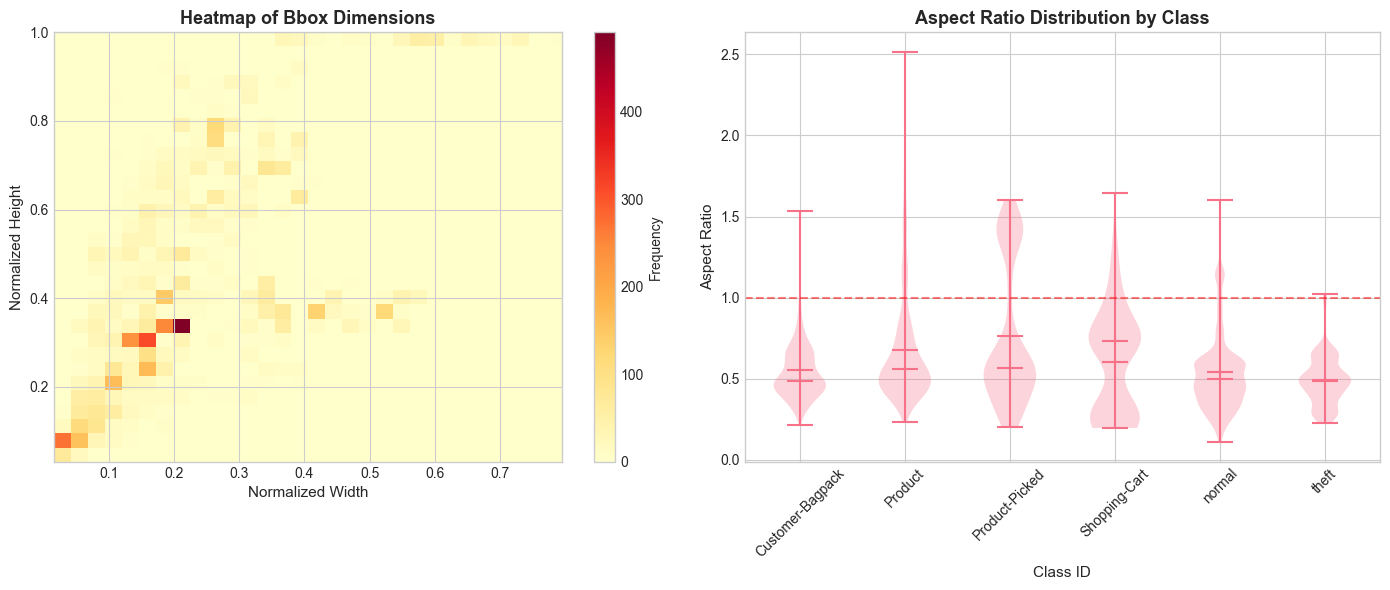

In [14]:
# Heatmap of bbox centers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# All classes combined
x_centers = bbox_df['norm_width'].values / 2 + (np.random.rand(len(bbox_df)) - 0.5) * 0.02  # Approx centers
y_centers = bbox_df['norm_height'].values / 2 + (np.random.rand(len(bbox_df)) - 0.5) * 0.02

# Use actual center positions from annotations
# For this we need to reload with center positions - let's use width/height as proxy distribution

heatmap, xedges, yedges = np.histogram2d(bbox_df['norm_width'], bbox_df['norm_height'], bins=30)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im = axes[0].imshow(heatmap.T, extent=extent, origin='lower', cmap='YlOrRd', aspect='auto')
axes[0].set_xlabel('Normalized Width', fontsize=11)
axes[0].set_ylabel('Normalized Height', fontsize=11)
axes[0].set_title('Heatmap of Bbox Dimensions', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Frequency')

# Aspect ratio by class violin plot
parts = axes[1].violinplot([bbox_df[bbox_df['class_id'] == i]['aspect_ratio'].values 
                            for i in sorted(bbox_df['class_id'].unique())],
                           positions=sorted(bbox_df['class_id'].unique()),
                           showmeans=True, showmedians=True)
axes[1].set_xlabel('Class ID', fontsize=11)
axes[1].set_ylabel('Aspect Ratio', fontsize=11)
axes[1].set_title('Aspect Ratio Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_xticks(sorted(bbox_df['class_id'].unique()))
axes[1].set_xticklabels([CLASS_NAMES[i] for i in sorted(bbox_df['class_id'].unique())], rotation=45)
axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Square')

plt.tight_layout()
plt.savefig(VIS_DIR / 'bbox_analysis_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Image Resolution Analysis

In [15]:
# Image resolution analysis
print("\n" + "="*70)
print("IMAGE RESOLUTION ANALYSIS")
print("="*70)

if len(image_df) > 0:
    print(f"\nTotal Images: {len(image_df):,}")
    print(f"\nImage Dimensions:")
    print(f"  Width  - Min: {image_df['width'].min()}, Max: {image_df['width'].max()}, Mean: {image_df['width'].mean():.1f}")
    print(f"  Height - Min: {image_df['height'].min()}, Max: {image_df['height'].max()}, Mean: {image_df['height'].mean():.1f}")
    print(f"\nAspect Ratio:")
    print(f"  Min: {image_df['aspect_ratio'].min():.3f}, Max: {image_df['aspect_ratio'].max():.3f}, Mean: {image_df['aspect_ratio'].mean():.3f}")
    
    # Common resolutions
    print("\nMost Common Resolutions:")
    image_df['resolution'] = image_df['width'].astype(str) + 'x' + image_df['height'].astype(str)
    resolution_counts = image_df['resolution'].value_counts().head(10)
    for res, count in resolution_counts.items():
        print(f"  {res}: {count:,} images ({count/len(image_df)*100:.1f}%)")


IMAGE RESOLUTION ANALYSIS

Total Images: 2,052

Image Dimensions:
  Width  - Min: 640, Max: 640, Mean: 640.0
  Height - Min: 640, Max: 640, Mean: 640.0

Aspect Ratio:
  Min: 1.000, Max: 1.000, Mean: 1.000

Most Common Resolutions:
  640x640: 2,052 images (100.0%)


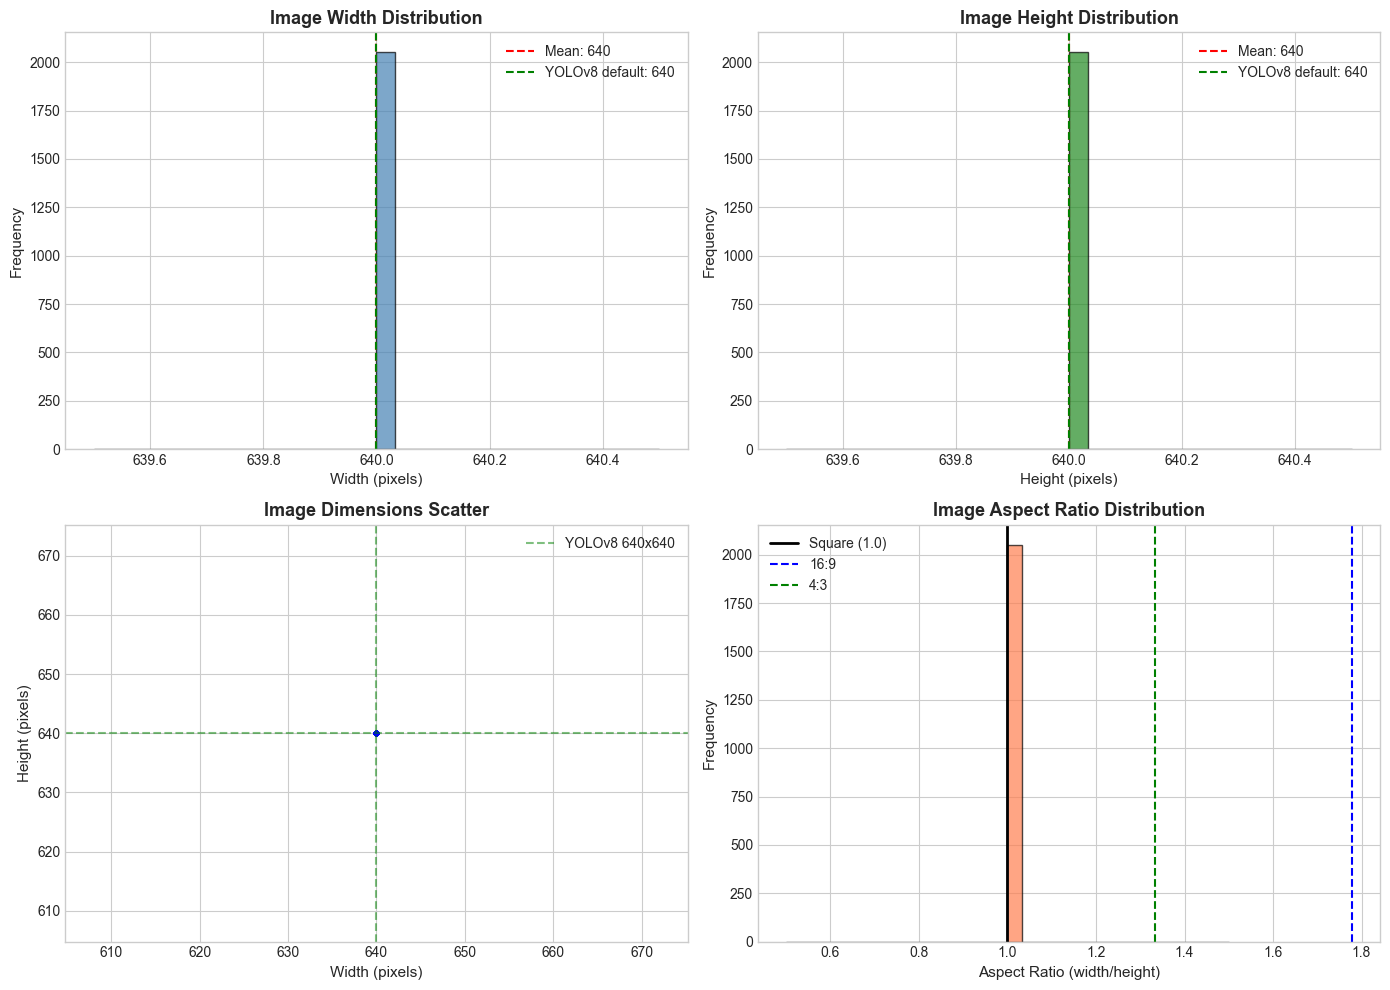

In [16]:
# Visualize image dimensions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width distribution
axes[0, 0].hist(image_df['width'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Width (pixels)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Image Width Distribution', fontsize=13, fontweight='bold')
axes[0, 0].axvline(image_df['width'].mean(), color='red', linestyle='--', label=f'Mean: {image_df["width"].mean():.0f}')
axes[0, 0].axvline(640, color='green', linestyle='--', label='YOLOv8 default: 640')
axes[0, 0].legend()

# Height distribution
axes[0, 1].hist(image_df['height'], bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Height (pixels)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Image Height Distribution', fontsize=13, fontweight='bold')
axes[0, 1].axvline(image_df['height'].mean(), color='red', linestyle='--', label=f'Mean: {image_df["height"].mean():.0f}')
axes[0, 1].axvline(640, color='green', linestyle='--', label='YOLOv8 default: 640')
axes[0, 1].legend()

# Width vs Height scatter
axes[1, 0].scatter(image_df['width'], image_df['height'], alpha=0.3, s=10, c='blue')
axes[1, 0].set_xlabel('Width (pixels)', fontsize=11)
axes[1, 0].set_ylabel('Height (pixels)', fontsize=11)
axes[1, 0].set_title('Image Dimensions Scatter', fontsize=13, fontweight='bold')
axes[1, 0].axhline(640, color='green', linestyle='--', alpha=0.5)
axes[1, 0].axvline(640, color='green', linestyle='--', alpha=0.5, label='YOLOv8 640x640')
axes[1, 0].legend()

# Aspect ratio distribution
axes[1, 1].hist(image_df['aspect_ratio'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Aspect Ratio (width/height)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Image Aspect Ratio Distribution', fontsize=13, fontweight='bold')
axes[1, 1].axvline(1.0, color='black', linestyle='-', linewidth=2, label='Square (1.0)')
axes[1, 1].axvline(16/9, color='blue', linestyle='--', label='16:9')
axes[1, 1].axvline(4/3, color='green', linestyle='--', label='4:3')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(VIS_DIR / 'image_resolution_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Annotations per Image Analysis

In [17]:
# Annotations per image analysis
print("\n" + "="*70)
print("ANNOTATIONS PER IMAGE ANALYSIS")
print("="*70)

if len(annot_df) > 0:
    print(f"\nAnnotations per Image:")
    print(f"  Min: {annot_df['num_annotations'].min()}")
    print(f"  Max: {annot_df['num_annotations'].max()}")
    print(f"  Mean: {annot_df['num_annotations'].mean():.2f}")
    print(f"  Median: {annot_df['num_annotations'].median():.0f}")
    print(f"  Std: {annot_df['num_annotations'].std():.2f}")
    
    # Empty images
    empty_count = (annot_df['num_annotations'] == 0).sum()
    print(f"\nImages with no annotations: {empty_count} ({empty_count/len(annot_df)*100:.1f}%)")


ANNOTATIONS PER IMAGE ANALYSIS

Annotations per Image:
  Min: 0
  Max: 7
  Mean: 3.57
  Median: 3
  Std: 1.85

Images with no annotations: 1 (0.0%)


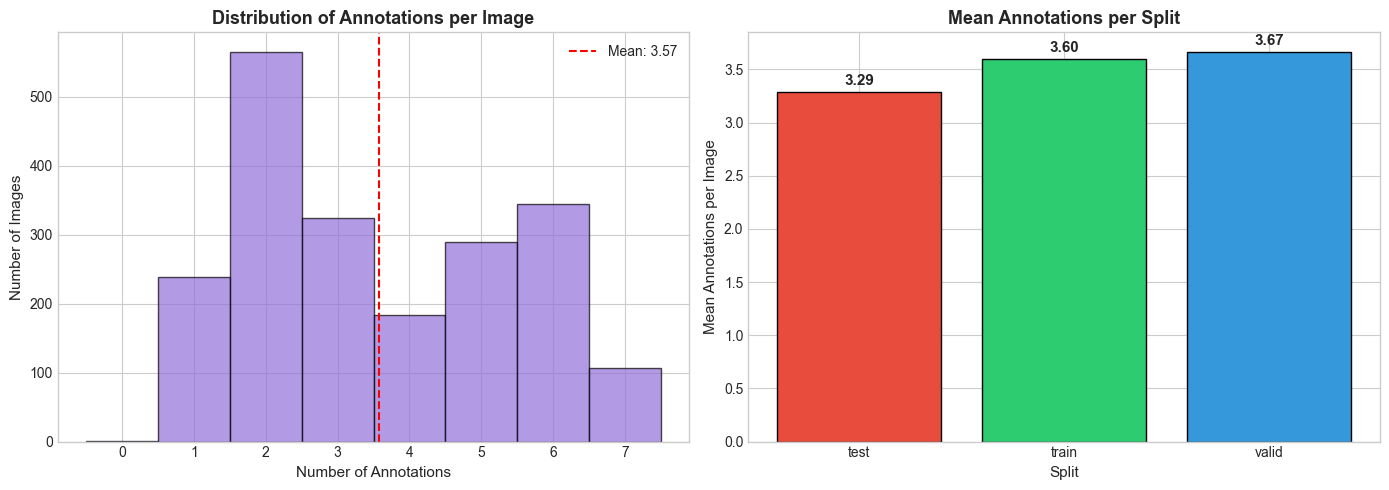

In [18]:
# Visualize annotations per image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(annot_df['num_annotations'], bins=range(0, annot_df['num_annotations'].max() + 2),
             color='mediumpurple', edgecolor='black', alpha=0.7, align='left')
axes[0].set_xlabel('Number of Annotations', fontsize=11)
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].set_title('Distribution of Annotations per Image', fontsize=13, fontweight='bold')
axes[0].axvline(annot_df['num_annotations'].mean(), color='red', linestyle='--', 
                label=f'Mean: {annot_df["num_annotations"].mean():.2f}')
axes[0].legend()

# By split
split_annot_means = annot_df.groupby('split')['num_annotations'].mean()
split_colors = {'train': '#2ecc71', 'valid': '#3498db', 'test': '#e74c3c'}
bars = axes[1].bar(split_annot_means.index, split_annot_means.values,
                   color=[split_colors.get(s, 'gray') for s in split_annot_means.index],
                   edgecolor='black')
axes[1].set_xlabel('Split', fontsize=11)
axes[1].set_ylabel('Mean Annotations per Image', fontsize=11)
axes[1].set_title('Mean Annotations per Split', fontsize=13, fontweight='bold')

for bar, val in zip(bars, split_annot_means.values):
    axes[1].annotate(f'{val:.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(VIS_DIR / 'annotations_per_image.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sample Image Visualization

In [19]:
def draw_bbox_on_image(image_path: Path, label_path: Path, ax, title: str = ""):
    """Draw bounding boxes on an image."""
    # Load image
    img = cv2.imread(str(image_path))
    if img is None:
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    ax.imshow(img)
    
    # Load and draw annotations
    annotations = load_annotations(label_path)
    
    for ann in annotations:
        class_id = ann['class_id']
        x_center = ann['x_center'] * w
        y_center = ann['y_center'] * h
        bbox_w = ann['width'] * w
        bbox_h = ann['height'] * h
        
        x1 = x_center - bbox_w / 2
        y1 = y_center - bbox_h / 2
        
        color = np.array(CLASS_COLORS.get(class_id, (128, 128, 128))) / 255
        
        rect = patches.Rectangle((x1, y1), bbox_w, bbox_h,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        # Add label
        label = CLASS_NAMES.get(class_id, f'Class {class_id}')
        ax.text(x1, y1 - 5, label, color=color, fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    
    ax.set_title(title, fontsize=10)
    ax.axis('off')

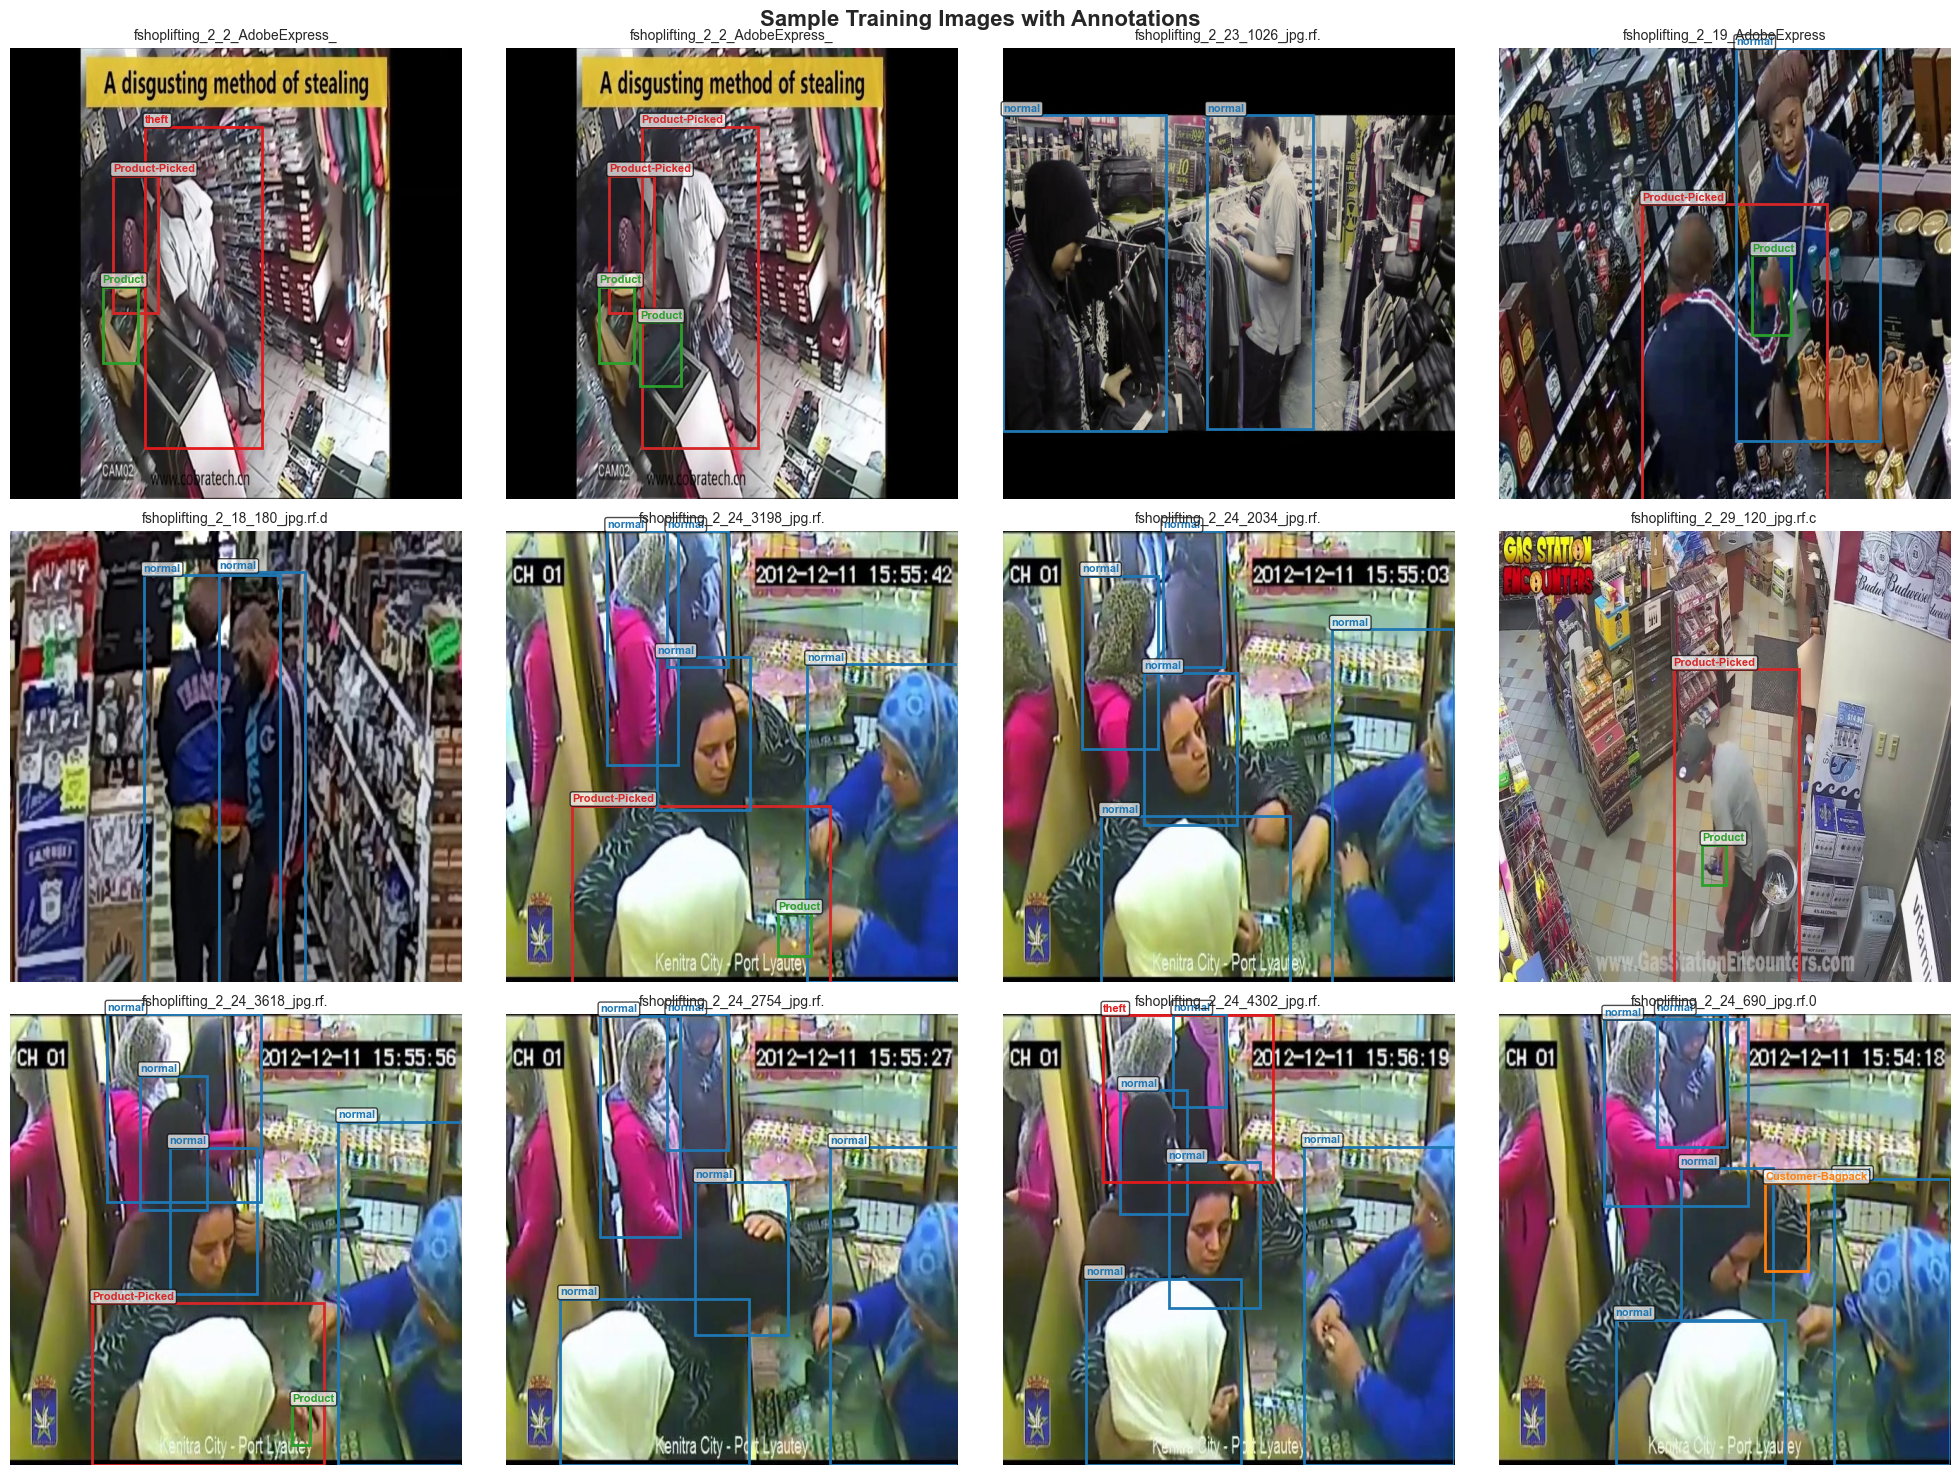

In [20]:
# Display sample images with annotations
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

# Get sample images from train split
train_images_path = DATASET_DIR / "train" / "images"
train_labels_path = DATASET_DIR / "train" / "labels"

if train_images_path.exists():
    image_files = list(train_images_path.glob("*.jpg")) + list(train_images_path.glob("*.png"))
    sample_images = random.sample(image_files, min(12, len(image_files)))
    
    for idx, img_path in enumerate(sample_images):
        label_path = train_labels_path / (img_path.stem + '.txt')
        draw_bbox_on_image(img_path, label_path, axes[idx], img_path.name[:30])

plt.suptitle('Sample Training Images with Annotations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(VIS_DIR / 'sample_images_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

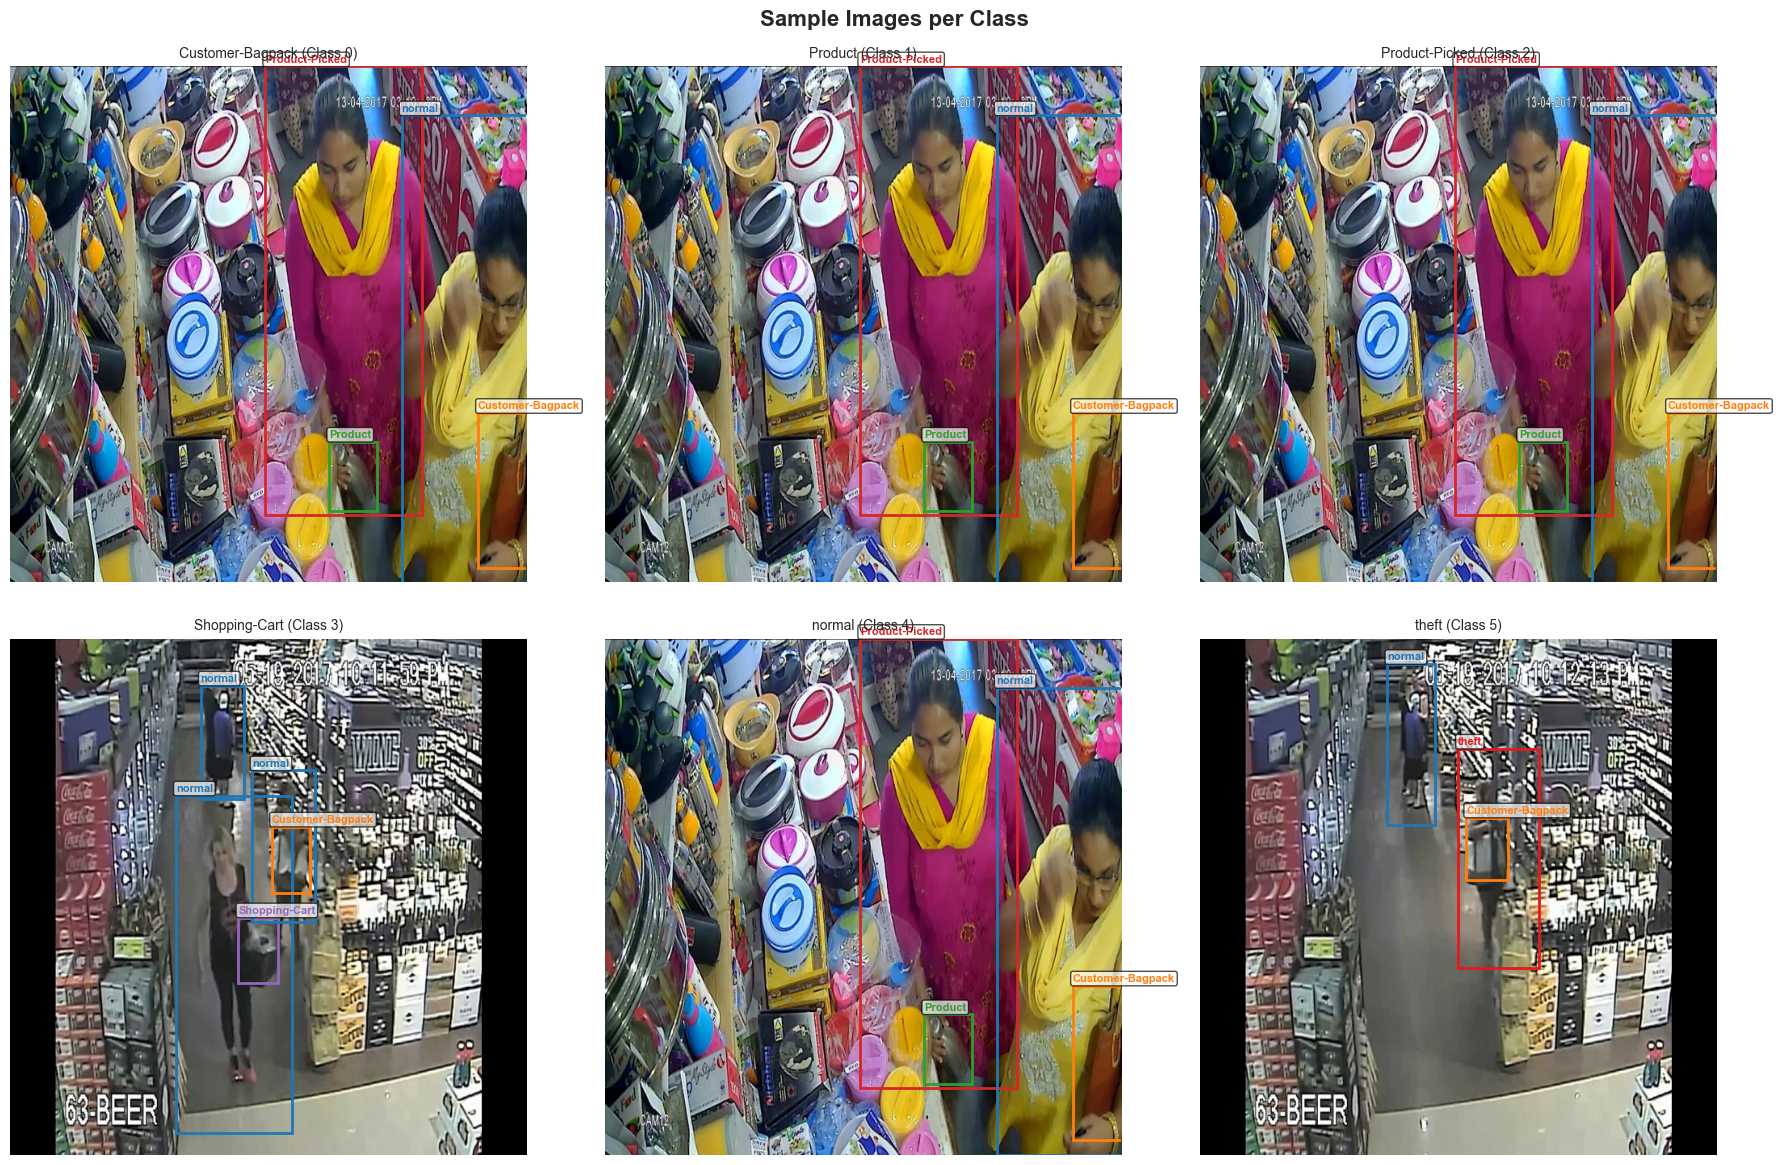

In [21]:
# Sample images per class
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Find images for each class
for idx, (class_id, class_name) in enumerate(CLASS_NAMES.items()):
    # Find images containing this class
    found = False
    
    for split in ['train', 'valid', 'test']:
        if found:
            break
        labels_path = DATASET_DIR / split / "labels"
        images_path = DATASET_DIR / split / "images"
        
        if not labels_path.exists():
            continue
        
        for label_file in labels_path.glob("*.txt"):
            annotations = load_annotations(label_file)
            if any(ann['class_id'] == class_id for ann in annotations):
                # Find corresponding image
                for ext in IMAGE_EXTENSIONS:
                    img_path = images_path / (label_file.stem + ext)
                    if img_path.exists():
                        draw_bbox_on_image(img_path, label_file, axes[idx], f'{class_name} (Class {class_id})')
                        found = True
                        break
            if found:
                break
    
    if not found:
        axes[idx].text(0.5, 0.5, f'No sample found for\n{class_name}', 
                       ha='center', va='center', fontsize=12)
        axes[idx].axis('off')

plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(VIS_DIR / 'sample_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Report

In [22]:
# Generate comprehensive summary report
summary_report = {
    'timestamp': datetime.now().isoformat(),
    'dataset_path': str(DATASET_DIR),
    'overview': {
        'total_images': len(image_df),
        'total_annotations': len(bbox_df),
        'avg_annotations_per_image': round(len(bbox_df) / len(image_df), 2) if len(image_df) > 0 else 0,
        'num_classes': NUM_CLASSES
    },
    'splits': {},
    'class_distribution': {
        CLASS_NAMES[k]: v for k, v in class_counts.items()
    },
    'class_imbalance': {
        'majority_class': majority_class,
        'minority_class': minority_class,
        'imbalance_ratio': round(imbalance_ratio, 2),
        'severity': severity
    },
    'bbox_statistics': {
        'area': {
            'mean': round(bbox_df['norm_area'].mean(), 4),
            'std': round(bbox_df['norm_area'].std(), 4),
            'min': round(bbox_df['norm_area'].min(), 4),
            'max': round(bbox_df['norm_area'].max(), 4)
        },
        'aspect_ratio': {
            'mean': round(bbox_df['aspect_ratio'].mean(), 3),
            'std': round(bbox_df['aspect_ratio'].std(), 3),
            'min': round(bbox_df['aspect_ratio'].min(), 3),
            'max': round(bbox_df['aspect_ratio'].max(), 3)
        }
    },
    'image_statistics': {
        'width': {
            'mean': round(image_df['width'].mean(), 1),
            'min': int(image_df['width'].min()),
            'max': int(image_df['width'].max())
        },
        'height': {
            'mean': round(image_df['height'].mean(), 1),
            'min': int(image_df['height'].min()),
            'max': int(image_df['height'].max())
        }
    }
}

# Add split statistics
for split, data in dataset_stats['splits'].items():
    summary_report['splits'][split] = {
        'num_images': data['num_images'],
        'num_annotations': data['num_annotations'],
        'percentage': round(data['num_images'] / len(image_df) * 100, 1) if len(image_df) > 0 else 0
    }

# Save report
report_path = OUTPUT_DIR / 'dataset_analysis_report.json'
with open(report_path, 'w') as f:
    json.dump(summary_report, f, indent=2)

print(f"Summary report saved to: {report_path}")

Summary report saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\outputs\dataset_analysis_report.json


In [23]:
# Print final summary
print("\n" + "="*70)
print("DATASET ANALYSIS SUMMARY")
print("="*70)

print(f"""
OVERVIEW:
---------
Total Images:           {summary_report['overview']['total_images']:,}
Total Annotations:      {summary_report['overview']['total_annotations']:,}
Avg Annotations/Image:  {summary_report['overview']['avg_annotations_per_image']}
Number of Classes:      {summary_report['overview']['num_classes']}

CLASS IMBALANCE:
----------------
Majority Class:   {summary_report['class_imbalance']['majority_class']}
Minority Class:   {summary_report['class_imbalance']['minority_class']}
Imbalance Ratio:  {summary_report['class_imbalance']['imbalance_ratio']}x
Severity:         {summary_report['class_imbalance']['severity']}

RECOMMENDATIONS FOR YOLOv8s TRAINING:
--------------------------------------
1. Use class-weighted loss to handle imbalance (focus on Theft, Shopping-Cart)
2. Apply targeted augmentation to minority classes
3. Consider oversampling Theft and Shopping-Cart classes
4. Use image size of 640x640 (standard for YOLOv8s)
5. Enable mosaic augmentation for training
6. Set focal loss gamma=1.5-2.0 for hard example mining
7. Use warmup epochs=3 and patience=50 for early stopping
""")

print("="*70)
print("\nVisualization files saved to:", VIS_DIR)
print("="*70)


DATASET ANALYSIS SUMMARY

OVERVIEW:
---------
Total Images:           2,052
Total Annotations:      7,335
Avg Annotations/Image:  3.57
Number of Classes:      6

CLASS IMBALANCE:
----------------
Majority Class:   normal
Minority Class:   Shopping-Cart
Imbalance Ratio:  33.77x
Severity:         CRITICAL

RECOMMENDATIONS FOR YOLOv8s TRAINING:
--------------------------------------
1. Use class-weighted loss to handle imbalance (focus on Theft, Shopping-Cart)
2. Apply targeted augmentation to minority classes
3. Consider oversampling Theft and Shopping-Cart classes
4. Use image size of 640x640 (standard for YOLOv8s)
5. Enable mosaic augmentation for training
6. Set focal loss gamma=1.5-2.0 for hard example mining
7. Use warmup epochs=3 and patience=50 for early stopping


Visualization files saved to: c:\Users\shaho\OneDrive - Nile University\Desktop\AletrixGrad\visualizations


---

## Next Steps

After analysis, proceed to:
1. **04_dataset_balancing.ipynb** - Address class imbalance with augmentation
2. **05_dataset_splitting.ipynb** - Stratified train/val/test split

---